# Sales Intelligence & Predictive Modeling

This notebook provides an end-to-end data science analysis of sales performance, ranging from basic descriptive statistics to advanced predictive modeling and market segmentation.

**Core Objectives:**
1. **Univariate Analysis:** Central tendency, dispersion, and shape.
2. **Bivariate Analysis:** Relationships, correlations, and multi-dimensional scatter plots.
3. **Feature Engineering:** Derived metrics like Revenue and Marketing Efficiency.
4. **Temporal Analysis:** Monthly trends over time.
5. **Predictive Modeling:** Linear Regression to forecast units sold.
6. **Market Segmentation:** K-Means clustering to identify distinct market segments.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

# Set plotting style
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['grid.color'] = 'white'

# Load data
df = pd.read_csv('sales_dataset.csv')
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.sort_values('date')
df.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold,date
110,2015,1,China,i4,SUV,Hybrid,118384,462540,56,0.97,6.29,1.2,10,368,2015-01-01
83,2015,1,France,3 Series,SUV,Hybrid,55827,425348,198,0.97,6.29,1.2,2,706,2015-01-01
678,2015,1,China,X5,SUV,Petrol,83517,190021,311,0.97,6.29,1.2,8,662,2015-01-01
761,2015,1,USA,7 Series,Electric,Hybrid,60186,305230,312,0.97,6.29,1.2,5,922,2015-01-01
201,2015,1,UK,X7,SUV,Diesel,76850,197525,62,0.97,6.29,1.2,2,211,2015-01-01


## 1. Univariate Analysis

Understanding the distribution of the target variable: `units_sold`.

Univariate Summary for 'units_sold':
           Metric         Value
0            Mean    633.192000
1          Median    630.000000
2            Mode    730.000000
3   Std Deviation    263.346628
4        Variance  69351.446583
5           Range   1227.000000
6             IQR    409.750000
7         Minimum     15.000000
8        Q1 (25%)    432.750000
9        Q3 (75%)    842.500000
10        Maximum   1242.000000
11       Skewness      0.031750
12       Kurtosis     -0.761037


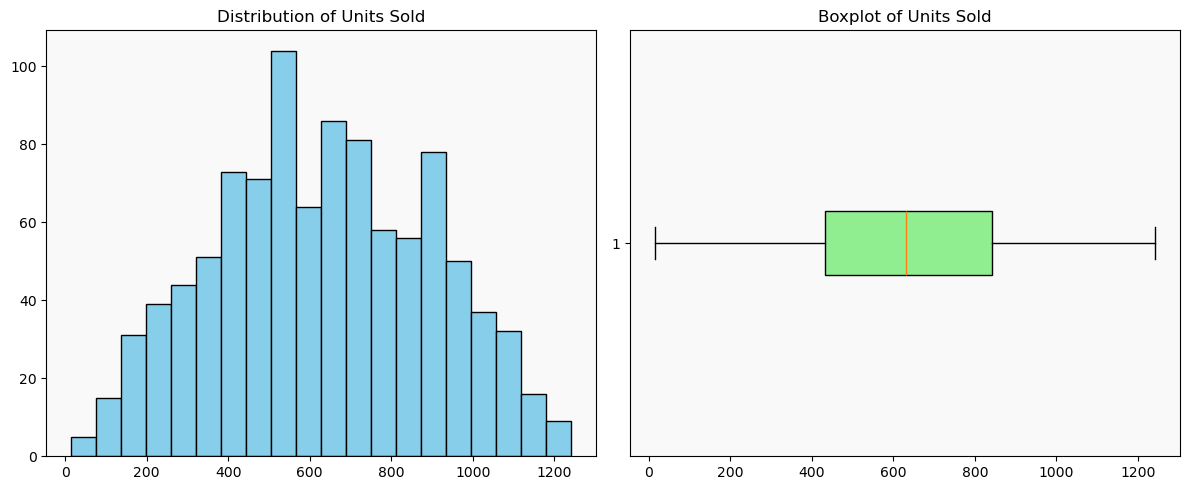

In [11]:
def univariate_summary(data, column):
    col_data = data[column]
    
    # Summary statistics
    summary = {
        'Metric': [
            'Mean', 'Median', 'Mode', 
            'Std Deviation', 'Variance', 'Range', 'IQR', 
            'Minimum', 'Q1 (25%)', 'Q3 (75%)', 'Maximum', 
            'Skewness', 'Kurtosis'
        ],
        'Value': [
            col_data.mean(), col_data.median(), col_data.mode()[0], 
            col_data.std(), col_data.var(), col_data.max() - col_data.min(), 
            col_data.quantile(0.75) - col_data.quantile(0.25),
            col_data.min(), col_data.quantile(0.25), col_data.quantile(0.75), col_data.max(), 
            col_data.skew(), col_data.kurtosis()
        ]
    }
    return pd.DataFrame(summary)

print("Univariate Summary for 'units_sold':")
print(univariate_summary(df, 'units_sold'))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['units_sold'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Units Sold')

plt.subplot(1, 2, 2)
plt.boxplot(df['units_sold'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Boxplot of Units Sold')
plt.tight_layout()
plt.show()

## 2. Bivariate & Multivariate Analysis

Exploring relationships between key drivers.

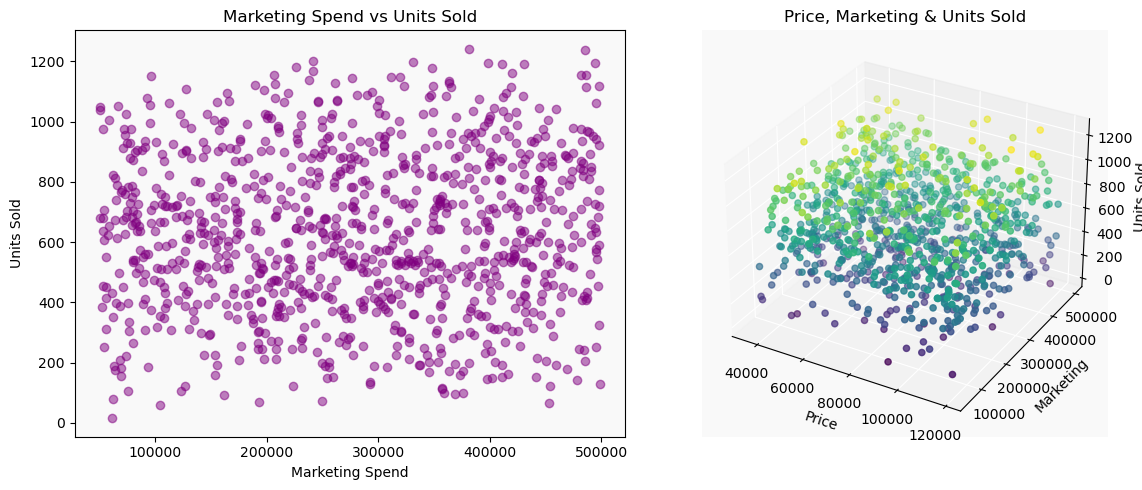

In [12]:
# 2D Scatter Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['marketing_spend_usd'], df['units_sold'], alpha=0.5, color='purple')
plt.title('Marketing Spend vs Units Sold')
plt.xlabel('Marketing Spend')
plt.ylabel('Units Sold')

# 3D Scatter Plot
ax = plt.subplot(1, 2, 2, projection='3d')
ax.scatter(df['price_usd'], df['marketing_spend_usd'], df['units_sold'], c=df['units_sold'], cmap='viridis')
ax.set_title('Price, Marketing & Units Sold')
ax.set_xlabel('Price')
ax.set_ylabel('Marketing')
ax.set_zlabel('Units Sold')

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Business Metrics

Creating derived metrics to uncover deeper insights.

In [13]:
df['total_revenue'] = df['price_usd'] * df['units_sold']
df['marketing_efficiency'] = df['units_sold'] / (df['marketing_spend_usd'] / 1000)
df['dealership_productivity'] = df['units_sold'] / df['dealership_count']

print("Top 5 Models by Revenue:")
print(df.groupby('model')['total_revenue'].sum().sort_values(ascending=False).head())

Top 5 Models by Revenue:
model
X3          5623524340
i4          5342875307
3 Series    5281929125
X5          5027126143
7 Series    4870343575
Name: total_revenue, dtype: int64


## 4. Temporal Trends

Tracking sales performance over time.

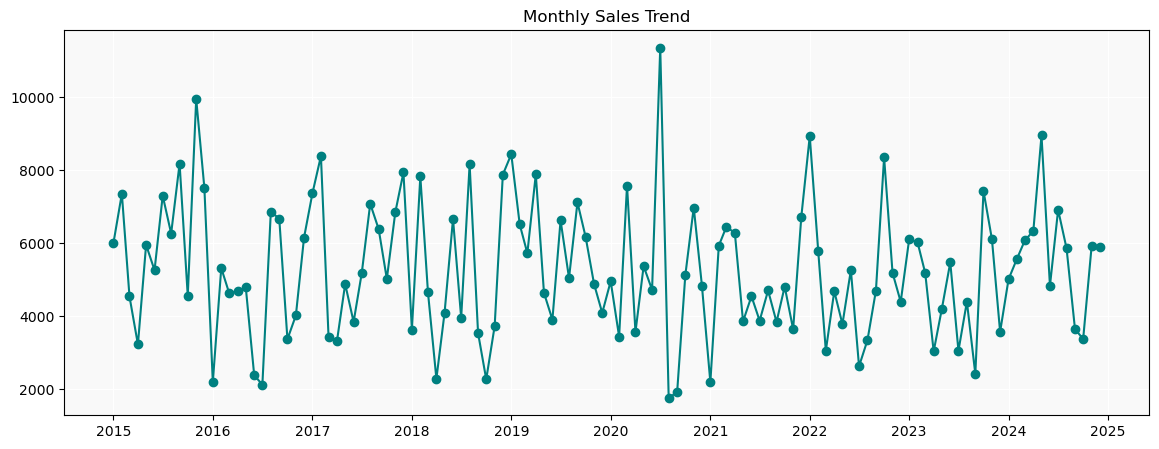

In [14]:
monthly_sales = df.groupby('date')['units_sold'].sum()
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.grid(True)
plt.show()

## 5. Predictive Modeling (Regression)

Predicting sales based on multiple factors.

R2 Score: 0.7924


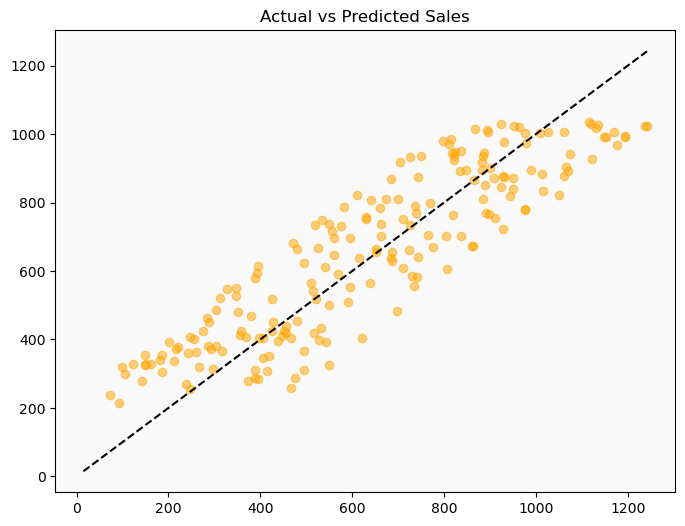

In [15]:
features = ['price_usd', 'marketing_spend_usd', 'dealership_count', 'competition_index']
X = df[features]
y = df['units_sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_model = LinearRegression().fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--k')
plt.title('Actual vs Predicted Sales')
plt.show()

## 6. Market Segmentation (Clustering)

Segmenting the market based on Price and Units Sold.

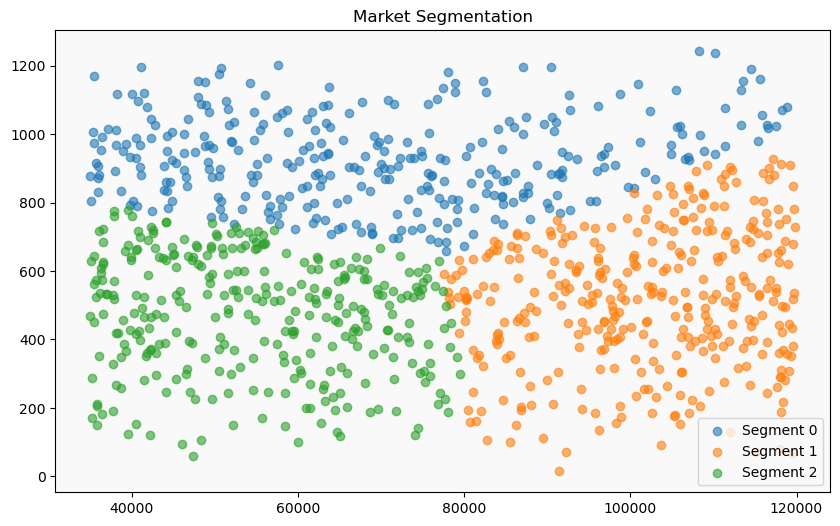

In [16]:
scaled_data = StandardScaler().fit_transform(df[['price_usd', 'units_sold']])
df['cluster'] = KMeans(n_clusters=3, random_state=42).fit_predict(scaled_data)

plt.figure(figsize=(10, 6))
for i in range(3):
    subset = df[df['cluster'] == i]
    plt.scatter(subset['price_usd'], subset['units_sold'], label=f'Segment {i}', alpha=0.6)
plt.title('Market Segmentation')
plt.legend()
plt.show()

## 7. Global Correlation Intelligence

A final view of how all metrics interact.

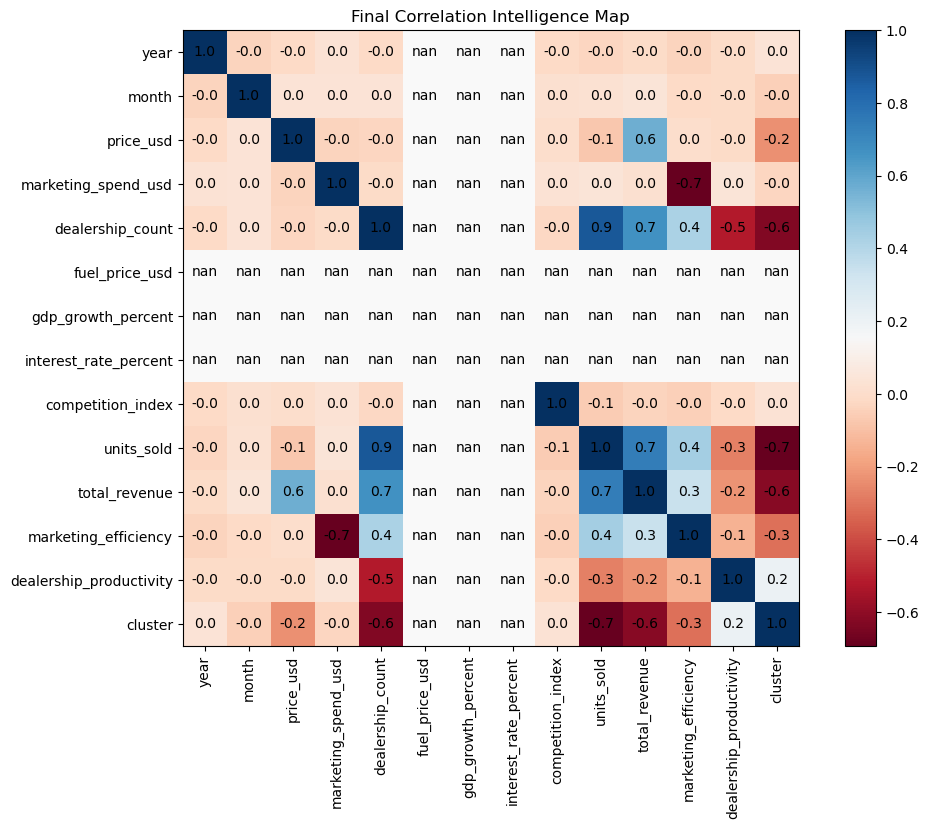

In [17]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap='RdBu', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f'{corr.iloc[i, j]:.1f}', ha='center', va='center')
plt.title('Final Correlation Intelligence Map')
plt.show()